# Task 3.1 - Neural Network in TensorFlow/Keras

## Objective
Build and train a feed-forward neural network in TensorFlow/Keras on the
California Housing dataset, using the same data split and architecture as the
Week 2 PyTorch model, then compare the results fairly.

## Matching the Week 2 PyTorch setup
| Setting | Value |
|---|---|
| Dataset | California Housing (scikit-learn) |
| Task | Regression (predict median house value) |
| Split | 80% train / 20% test, random_state=42 |
| Scaling | StandardScaler on features only (fit on train) |
| Architecture | 8 -> 32 -> 16 -> 1, ReLU |
| Loss / Optimizer | MSE / Adam, lr=0.001 |
| Batch size / Epochs | 32 / 50 |

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("NumPy version:", np.__version__)
print("Devices:", tf.config.list_physical_devices())

TensorFlow version: 2.21.0
Keras version: 3.15.1
NumPy version: 2.4.6
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Load Dataset
We use the same California Housing dataset as Week 2 (20,640 rows, 8 features,
target = median house value). Loading it the same way keeps the comparison fair.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
df.head()

Shape: (20640, 9)
Missing values: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Preprocessing
Same steps as the Week 2 PyTorch notebook:
1. Separate features (X) from target (y)
2. 80/20 train/test split with random_state=42
3. Scale features with StandardScaler (fit on training data only, to avoid data leakage)
4. Target is NOT scaled (same as Week 2)

Keras works directly with NumPy arrays, so no tensor conversion or Dataset/DataLoader
is needed here, unlike PyTorch.

In [3]:
# 1. Separate features and target
X = df.drop(columns=["MedHouseVal"]).values
y = df["MedHouseVal"].values

# 2. Train/test split (same settings as Week 2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Scale features (fit ONLY on training data, then apply to both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Convert to float32 (Keras default; matches PyTorch's float32)
X_train_scaled = X_train_scaled.astype("float32")
X_test_scaled = X_test_scaled.astype("float32")
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

print("X_train shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test_scaled.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (16512, 8)
y_train shape: (16512,)
X_test shape:  (4128, 8)
y_test shape:  (4128,)


## Define and Compile the Model
Same architecture as the Week 2 PyTorch model: 8 -> 32 -> 16 -> 1 with ReLU.

| PyTorch (Week 2) | Keras (this notebook) |
|---|---|
| `nn.Linear(8, 32)` + `nn.ReLU()` | `Dense(32, activation="relu")` |
| `nn.Linear(32, 16)` + `nn.ReLU()` | `Dense(16, activation="relu")` |
| `nn.Linear(16, 1)` | `Dense(1)` |
| `nn.MSELoss()` | `loss="mse"` |
| `Adam(lr=0.001)` | `Adam(learning_rate=0.001)` |

In Keras, `compile()` attaches the loss, optimizer and metrics to the model.
This replaces the manual setup we wrote in PyTorch.

In [4]:
# Fix the random seed so results are reproducible
keras.utils.set_random_seed(42)

model = keras.Sequential([
    keras.layers.Input(shape=(8,)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

## Training
Trained for 50 epochs with batch size 32, as in Week 2. The test set is passed as
`validation_data` only to record test loss after every epoch. It does not change the
weights, and no tuning decisions are made from it (no early stopping), so it matches
how Week 2 compared train and test loss. Training time is measured with `time.perf_counter()`.

In [5]:
start_time = time.perf_counter()

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_data=(X_test_scaled, y_test),
    verbose=0,
)

training_time = time.perf_counter() - start_time

# Print progress every 5 epochs (same style as Week 2)
for epoch in range(4, 50, 5):
    print(f"Epoch {epoch+1}/50 - Train Loss: {history.history['loss'][epoch]:.4f} "
          f"- Test Loss: {history.history['val_loss'][epoch]:.4f}")

print(f"\nTraining time: {training_time:.1f} seconds")

Epoch 5/50 - Train Loss: 0.3661 - Test Loss: 0.3805
Epoch 10/50 - Train Loss: 0.3317 - Test Loss: 0.3572
Epoch 15/50 - Train Loss: 0.3057 - Test Loss: 0.3349
Epoch 20/50 - Train Loss: 0.2954 - Test Loss: 0.3250
Epoch 25/50 - Train Loss: 0.2894 - Test Loss: 0.3206
Epoch 30/50 - Train Loss: 0.2834 - Test Loss: 0.3127
Epoch 35/50 - Train Loss: 0.2783 - Test Loss: 0.3102
Epoch 40/50 - Train Loss: 0.2789 - Test Loss: 0.3010
Epoch 45/50 - Train Loss: 0.2735 - Test Loss: 0.2983
Epoch 50/50 - Train Loss: 0.2697 - Test Loss: 0.2916

Training time: 70.6 seconds


## Evaluation
We evaluate the final trained model on both the training set and the held-out test set,
using MSE (the training loss), MAE and R-squared. Evaluating the training set again with
the final weights gives a cleaner train number than the running average shown during training.

In [6]:
from sklearn.metrics import r2_score

# Final-weights evaluation (returns [loss, mae])
train_mse, train_mae = model.evaluate(X_train_scaled, y_train, verbose=0)
test_mse, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)

# R-squared needs the predictions
test_preds = model.predict(X_test_scaled, verbose=0).squeeze()
test_r2 = r2_score(y_test, test_preds)

print(f"Train MSE: {train_mse:.4f} | Train MAE: {train_mae:.4f}")
print(f"Test  MSE: {test_mse:.4f} | Test  MAE: {test_mae:.4f}")
print(f"Test  RMSE: {np.sqrt(test_mse):.4f}")
print(f"Test  R-squared: {test_r2:.4f}")

Train MSE: 0.2683 | Train MAE: 0.3561
Test  MSE: 0.2916 | Test  MAE: 0.3680
Test  RMSE: 0.5400
Test  R-squared: 0.7774


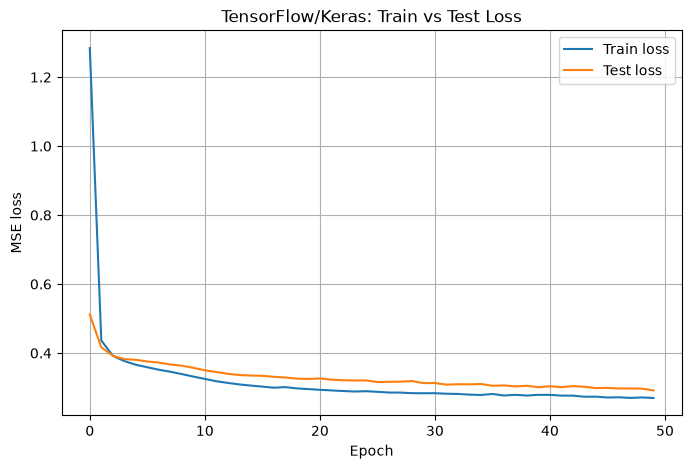

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("TensorFlow/Keras: Train vs Test Loss")
plt.legend()
plt.grid(True)
plt.savefig("../results/keras_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
sample_preds = model.predict(X_test_scaled[:10], verbose=0).squeeze()

comparison = pd.DataFrame({
    "Actual": y_test[:10],
    "Predicted": sample_preds,
})
comparison["Difference"] = comparison["Actual"] - comparison["Predicted"]
comparison

,Actual,Predicted,Difference
0,0.47700,0.402183,0.074817
1,0.45800,1.023332,-0.565332
2,5.00001,4.558651,0.441359
3,2.18600,2.599512,-0.413512
4,2.78000,2.946873,-0.166873
5,1.58700,1.630930,-0.043930
6,1.98200,2.494982,-0.512982
7,1.57500,1.642161,-0.067161
8,3.40000,2.746120,0.653880
9,4.46600,4.688773,-0.222773


In [9]:
import json
import platform

results = {
    "framework": "TensorFlow/Keras",
    "tensorflow_version": tf.__version__,
    "keras_version": keras.__version__,
    "python_version": platform.python_version(),
    "device": "CPU",
    "dataset": "California Housing",
    "train_samples": int(X_train_scaled.shape[0]),
    "test_samples": int(X_test_scaled.shape[0]),
    "epochs": 50,
    "batch_size": 32,
    "learning_rate": 0.001,
    "random_seed": 42,
    "parameters": int(model.count_params()),
    "train_mse": round(float(train_mse), 4),
    "train_mae": round(float(train_mae), 4),
    "test_mse": round(float(test_mse), 4),
    "test_mae": round(float(test_mae), 4),
    "test_rmse": round(float(np.sqrt(test_mse)), 4),
    "test_r2": round(float(test_r2), 4),
    "final_epoch_running_train_loss": round(float(history.history["loss"][-1]), 4),
    "training_time_seconds": round(training_time, 1),
}

with open("../results/keras_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))

{
  "framework": "TensorFlow/Keras",
  "tensorflow_version": "2.21.0",
  "keras_version": "3.15.1",
  "python_version": "3.11.9",
  "device": "CPU",
  "dataset": "California Housing",
  "train_samples": 16512,
  "test_samples": 4128,
  "epochs": 50,
  "batch_size": 32,
  "learning_rate": 0.001,
  "random_seed": 42,
  "parameters": 833,
  "train_mse": 0.2683,
  "train_mae": 0.3561,
  "test_mse": 0.2916,
  "test_mae": 0.368,
  "test_rmse": 0.54,
  "test_r2": 0.7774,
  "final_epoch_running_train_loss": 0.2697,
  "training_time_seconds": 70.6
}


## Comparison with PyTorch
Both models use the same data split, scaling, architecture (833 parameters), loss, optimizer,
batch size, epochs and seed value, and both ran on the CPU. PyTorch numbers come from
`pytorch_rerun_for_comparison.ipynb` (seed 42). Each framework was run once, so small
differences may be run-to-run noise rather than a framework effect.

In [2]:
import json
import pandas as pd
import json

with open("../results/pytorch_results.json") as f:
    pt = json.load(f)
with open("../results/keras_results.json") as f:
    kr = json.load(f)

rows = [
    ("Test MSE (loss)",            "test_mse"),
    ("Test MAE",                   "test_mae"),
    ("Test RMSE",                  "test_rmse"),
    ("Test R-squared",             "test_r2"),
    ("Train MSE (final weights)",  "train_mse"),
    ("Train MAE (final weights)",  "train_mae"),
    ("Final-epoch running train loss", "final_epoch_running_train_loss"),
    ("Training time (seconds)",    "training_time_seconds"),
    ("Parameters",                 "parameters"),
]

comparison_df = pd.DataFrame({
    "Metric": [label for label, _ in rows],
    "PyTorch": [pt[key] for _, key in rows],
    "TensorFlow/Keras": [kr[key] for _, key in rows],
})

comparison_df.to_csv("../results/comparison_table.csv", index=False)
comparison_df

,Metric,PyTorch,TensorFlow/Keras
0,Test MSE (loss),0.2877,0.2916
1,Test MAE,0.3597,0.3680
2,Test RMSE,0.5364,0.5400
3,Test R-squared,0.7805,0.7774
4,Train MSE (final weights),0.2697,0.2683
5,Train MAE (final weights),0.3505,0.3561
6,Final-epoch running train loss,0.2686,0.2697
7,Training time (seconds),39.0000,70.6000
8,Parameters,833.0000,833.0000


## Conclusions and Limitations
- The Keras model matches PyTorch closely (test MSE 0.2916 vs 0.2877, R-squared 0.7774 vs 0.7805).
- The PyTorch-vs-Keras gap is no larger than the gap between two PyTorch runs (0.2921 in Week 2, 0.2877 in the re-run), so it cannot be attributed to the framework.
- Training time was 70.6 s in Keras and 39.0 s in PyTorch on CPU, from a single run each.
- Limitations: one run per framework, no repeated seeds, simple tabular task.

Full notes: `results/comparison_notes.md`